In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('blinkit_10M.csv')

In [3]:
##data info 
# df.shape
# df.duplicated().sum()
# df.info() 
# df.isnull().sum()

### Problem 1: Null Values in the Customer City Column

**Solution:**
Identified a pattern in the `Store_ID` column where the city code was embedded within the ID. Extracted the city code from `Store_ID`, created a new `City` column, mapped the city codes to their corresponding full city names, and then dropped the original `City` column containing null values.


In [4]:
df[df['customer_city'].isnull()].head(5)

,order_id,order_date,customer_city,store_id,product_id,product_category,product_brand,quantity,selling_price,mrp,discount_pct,delivery_time_min,payment_method,customer_rating,delivery_partner
63,ORD-20250528-000063,2025-05-28,NaN,DS-BEN-07,P-PER19,Personal Care,Himalaya,2,245,315,22.22,8,UPI,4.8,Shadowfax
126,ORD-20250703-000126,2025-07-03,NaN,DS-PUN-01,P-BEV19,Beverages,Coca-Cola,3,148,210,29.49,16,Card,3.7,Shadowfax
493,ORD-20250208-000493,2025-02-08,NaN,DS-MUM-02,P-BEV3,Beverages,Thums Up,4,219,240,8.89,9,Card,5.0,Zomato
574,ORD-20250719-000574,2025-07-19,NaN,DS-DEL-02,P-BEV9,Beverages,Red Bull,4,48,65,26.04,13,Cash,4.6,Blinkit
776,ORD-20250322-000776,2025-03-22,NaN,DS-DEL-10,P-SNA14,Snacks,Britannia,5,35,45,22.83,10,Cash,4.7,Zomato


In [5]:
df["City_code"]=df['store_id'].str.split('-').str[1]

In [6]:
df=df.rename(columns={'City_code':'city'})

In [7]:
City_map={
    'CHE':'Chennai',
    'PUN':'Pune',
    'DEL':'Delhi',
    'BEN':'Bengaluru',
    'HYD':'Hyderabad',
    'MUM':'Mumbai'
}

df['city']=df['city'].replace(City_map)

In [8]:
df=df.drop(columns='customer_city')

##  Feature Engineering for Delivery Time

**Solution:**
Created new features from the `delivery_time_min` column to make the data more useful for future analysis.

The delivery time was categorized into three groups:

* **Fast** → 30 minutes or less
* **Moderate** → 31–60 minutes
* **Slow** → More than 60 minutes

A new **Delivery Category** column was created to analyze delivery performance and identify patterns between delivery time and other factors such as **customer ratings, city, discounts, product brands, and quantity purchased**.

This feature will also help with future **delivery performance analysis and customer experience analysis**.


In [9]:
df['delivery_time_min']=df['delivery_time_min'].astype('int32')

In [10]:
def del_time(time):
    if time <= 30:
        return 'Fast'
    elif time <= 60:
        return 'Moderate'
    else:
        return 'Slow'

df['Delivery_Category'] = df['delivery_time_min'].apply(del_time)

## Problem 2: Missing Values in the Customer Rating Column

**Solution:**
Instead of filling the missing ratings with an estimated value, I will replace the missing values with **"Rating Not Given"**.

This allows us to preserve the original information and perform further analysis to understand **why customers did not provide a rating**.

This can help identify patterns related to factors such as:

* Delivery time
* City
* Discount percentage
* Customer experience

The goal is to use this analysis to identify possible reasons for missing ratings and determine strategies to **increase the customer rating response rate** in the future.


In [11]:
df['customer_rating']=df['customer_rating'].fillna("Rating not given")

## Problem 3: Date Formatting and Feature Extraction

**Solution:**
The date column was cleaned and converted into a proper datetime format. From the date, additional features were created to support time-based analysis.

The following columns were created:

* **Year** – Extracted the year from the date.
* **Month** – Extracted the numerical month.
* **Month Name** – Extracted the month name for easier visualization.
* **Day** – Extracted the day of the month.
* **Day_name** - Extracted the day_name of the month.
These features will help analyze **sales trends, customer behavior, delivery performance, and other patterns across different time periods**.


In [12]:
df['order_date']=pd.to_datetime(df['order_date'])

In [13]:
Date_columns=["Year","Month","Day","Month_name","Day_name","Quarter"]

for i in Date_columns:
    if i == 'Year':
        df[f'order{i}']=df['order_date'].dt.year
    elif i == 'Month':
        df[f'order{i}']=df['order_date'].dt.month
    elif i == 'Month_name':
        df[f'order{i}']=df['order_date'].dt.month_name()
    elif i == 'Day':
        df[f'order{i}']=df['order_date'].dt.day
    elif i == 'Day_name':
        df[f'order{i}']=df['order_date'].dt.day_name()
    elif i == 'Quarter':
        df[f'order{i}']=df['order_date'].dt.quarter

## Problem 4: Incorrect Discount Values and Price Adjustment Analysis

### Problem
The existing discount values in the dataset were incorrect and did not accurately represent the difference between **MRP** and **Selling Price**. Therefore, the original discount column was not used for the analysis.

### Solution
A new pricing analysis was created using **MRP** and **Selling Price**.

The following columns were created:

- **Total_Discount** – Calculates the discount amount when the Selling Price is lower than the MRP. Otherwise, returns `0`.
- **Total_Hike** – Calculates the price increase when the Selling Price is higher than the MRP. Otherwise, returns `0`.
- **Price_Category** – Classifies each product as:
  - `Discounted`
  - `Hiked`
  - `Same Price`

### Calculation

**Total Discount**

`MRP - Selling Price` when Selling Price < MRP, otherwise `0`.

**Total Hike**

`Selling Price - MRP` when Selling Price > MRP, otherwise `0`.

This provides a more accurate view of the actual **discounts, price hikes, and pricing behavior** across products and supports further **product-level, brand-level, category-level, and pricing analysis**.

In [14]:
df=df.drop(columns='discount_pct')

In [15]:
df['Total_Discount'] = 0
df.loc[df['selling_price'] < df['mrp'],'Total_Discount'] = df['mrp'] - df['selling_price']
df['Price_Category'] = 'Hiked'
df.loc[df['selling_price'] < df['mrp'],'Price_Category'] = 'Discounted'

In [16]:
df['Total_Hike'] = 0
df.loc[df['selling_price'] > df['mrp'],'Total_Hike'] = df['selling_price'] - df['mrp']

In [17]:
df['Price_Category'].value_counts()

Price_Category
Discounted    10047635
Hiked           152365
Name: count, dtype: int64

## Problem 5: Creating Quantity Categories

**Solution:**
Created a new **Quantity Category** column to classify orders based on the quantity purchased.

The categories are:

* **Single** → Quantity = 1
* **Multiple** → Quantity between 2 and 5
* **Bulk** → Quantity greater than 5

This categorization will help analyze **customer purchasing behavior, order patterns, and bulk purchasing trends**.


In [18]:
def que_calcu(q):
    if q == 1:
        return 'Single'
    elif q <= 5:
        return 'Multiple'
    else:
        return 'Bulk'

df['Quantity_Category'] = df['quantity'].apply(que_calcu)

## Exporting data For final changes 

In [19]:
df.to_csv("Blinkit_Final_data.csv",index=False)

## Dashboard

## KPI

In [20]:
total_orders = df['order_id'].nunique()
total_quantity = df['quantity'].sum()
total_revenue = df['mrp'].sum()
average_order_value = df['mrp'].mean()
average_rating = pd.to_numeric(df['customer_rating'],errors='coerce').mean()
average_delivery_time = df['delivery_time_min'].mean()
print(f"Total Orders: {total_orders:,}")
print(f"Total Quantity: {total_quantity:,}")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Average Rating: {average_rating:.2f}")
print(f"Average Delivery Time: {average_delivery_time:.2f} min")

Total Orders: 9,897,732
Total Quantity: 25,595,548
Total Revenue: ₹1,944,675,950.00
Average Order Value: ₹190.65
Average Rating: 4.32
Average Delivery Time: 13.75 min


## Charts for Dashboard 1

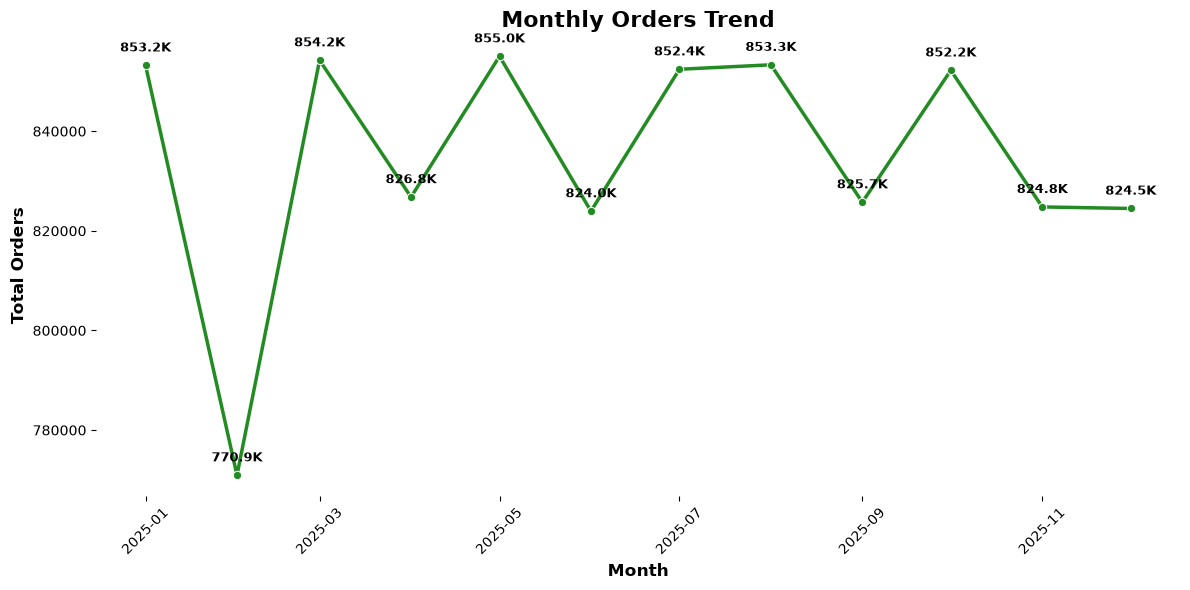

In [21]:
monthly_orders = df.groupby(df['order_date'].dt.to_period('M')).agg(Total_Orders=('order_id', 'nunique')).reset_index()
monthly_orders['order_date'] = monthly_orders['order_date'].dt.to_timestamp()
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=monthly_orders,x='order_date',y='Total_Orders',marker='o',color='forestgreen',linewidth=2.5)
ax.set_title('Monthly Orders Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Orders', fontsize=12, fontweight='bold')
for x, y in zip(monthly_orders['order_date'], monthly_orders['Total_Orders']):
    label = f'{y / 1_000_000:.2f}M' if y >= 1_000_000 else f'{y / 1_000:.1f}K'
    ax.annotate(label,(x, y),textcoords="offset points",xytext=(0, 10),ha='center',fontsize=9,fontweight='bold')
plt.xticks(rotation=45)
sns.despine(top=True, right=True,bottom=True,left=True)
plt.tight_layout()
plt.show()

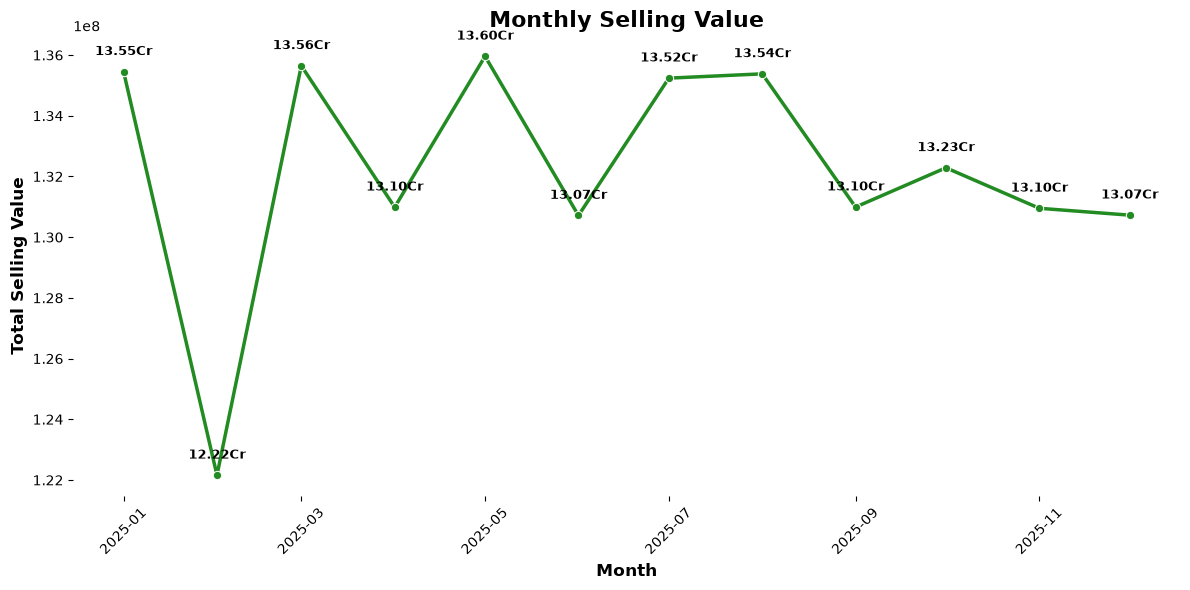

In [22]:
monthly_sales = df.groupby(df['order_date'].dt.to_period('M')).agg(Total_Selling_Value=('selling_price', 'sum')).reset_index()
monthly_sales['order_date'] = monthly_sales['order_date'].dt.to_timestamp()
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=monthly_sales,x='order_date',y='Total_Selling_Value',marker='o',color='forestgreen',linewidth=2.5)
ax.set_title('Monthly Selling Value', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Selling Value', fontsize=12, fontweight='bold')
for x, y in zip(monthly_sales['order_date'], monthly_sales['Total_Selling_Value']):
    label = (
        f'{y / 10_000_000:.2f}Cr' if y >= 10_000_000
        else f'{y / 100_000:.2f}L' if y >= 100_000
        else f'{y / 1_000:.1f}K')
    ax.annotate(label,(x, y),textcoords="offset points",xytext=(0, 12),ha='center',fontsize=9,fontweight='bold')
plt.xticks(rotation=45)
sns.despine(top=True, right=True,bottom=True,left=True)
plt.tight_layout()
plt.show()

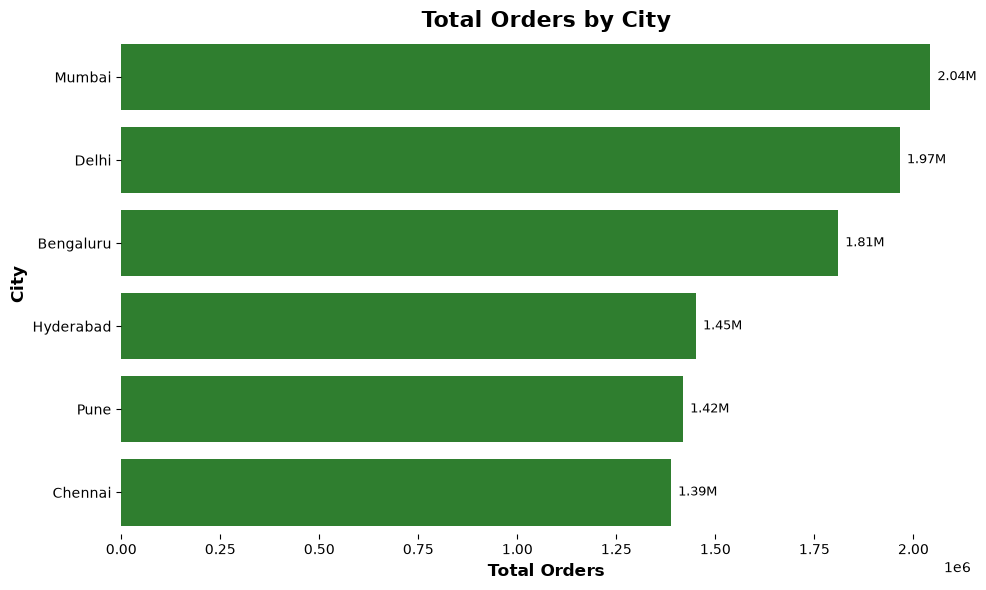

In [23]:
city_orders = df.groupby('city').agg(Total_Orders=('order_id', 'nunique')).reset_index().sort_values('Total_Orders',ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=city_orders,y='city',x='Total_Orders',color='forestgreen')
ax.set_title('Total Orders by City',fontsize=16,fontweight='bold')
ax.set_xlabel('Total Orders',fontsize=12,fontweight='bold')
ax.set_ylabel('City',fontsize=12,fontweight='bold')
for i in ax.containers:
    ax.bar_label(i,labels=[f"{v / 1_000_000:.2f}M" if v >= 1_000_000 else f"{v / 1_000:.1f}K"for v in city_orders['Total_Orders']],fontsize=9,padding=5)
sns.despine(top=True, right=True,bottom=True,left=True)
plt.tight_layout()
plt.show()

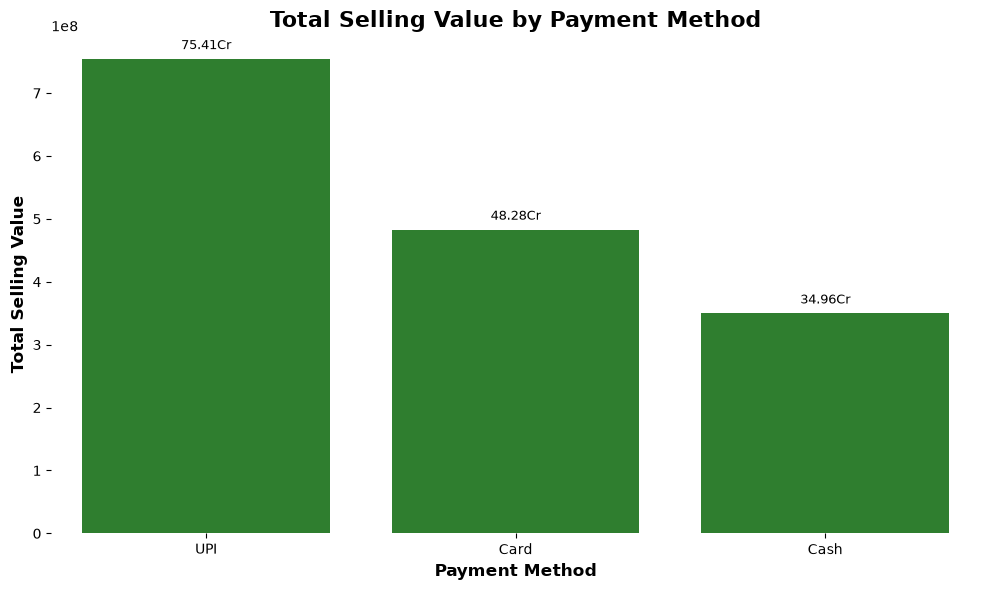

In [24]:
payment_sales = df.groupby('payment_method').agg(Total_Selling_Value=('selling_price', 'sum')).reset_index().sort_values('Total_Selling_Value',ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=payment_sales,x='payment_method',y='Total_Selling_Value',color='forestgreen')
ax.set_title('Total Selling Value by Payment Method', fontsize=16, fontweight='bold')
ax.set_xlabel('Payment Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Selling Value', fontsize=12, fontweight='bold')
for container in ax.containers:
    labels = [
        f"{v / 10_000_000:.2f}Cr" if v >= 10_000_000 
        else f"{v / 100_000:.2f}L" if v >= 100_000 
        else f"{v / 1_000:.1f}K" 
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, fontsize=9, padding=5)
sns.despine(top=True, right=True)
sns.despine(top=True, right=True,bottom=True,left=True)
plt.tight_layout()
plt.show()

## Charts for Dashboard 2

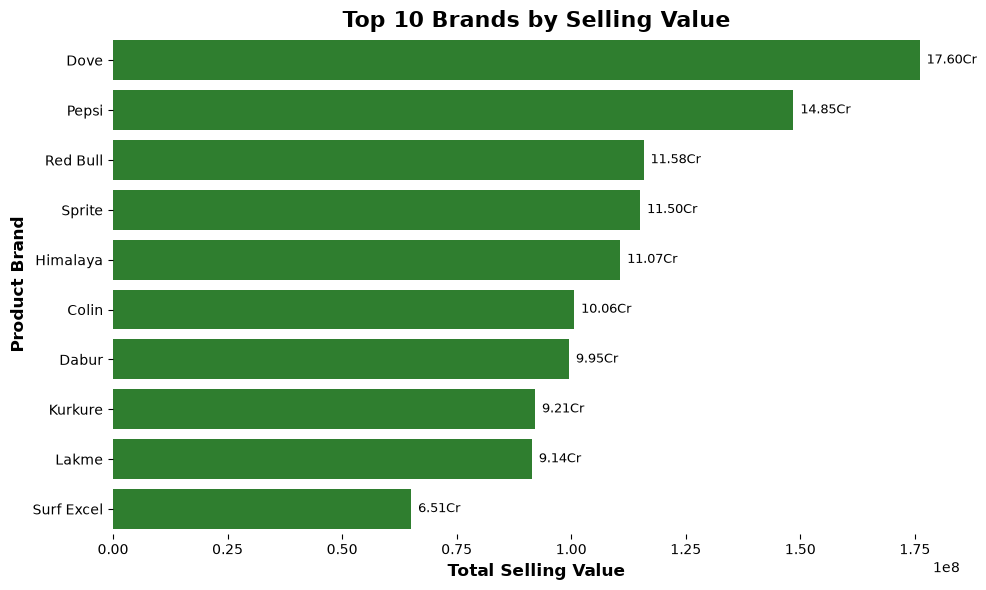

In [25]:
brand_sales = df.groupby('product_brand').agg(Total_Selling_Value=('selling_price', 'sum')).reset_index().sort_values('Total_Selling_Value',ascending=False).head(10)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=brand_sales,x='Total_Selling_Value',y='product_brand',color='forestgreen')
ax.set_title('Top 10 Brands by Selling Value', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Selling Value', fontsize=12, fontweight='bold')
ax.set_ylabel('Product Brand', fontsize=12, fontweight='bold')
for container in ax.containers:
    labels = [
        f"{v / 10_000_000:.2f}Cr" if v >= 10_000_000 
        else f"{v / 100_000:.2f}L" if v >= 100_000 
        else f"{v / 1_000:.1f}K" 
        for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9, padding=5)
sns.despine(top=True, right=True,bottom=True,left=True)
plt.tight_layout()
plt.show()

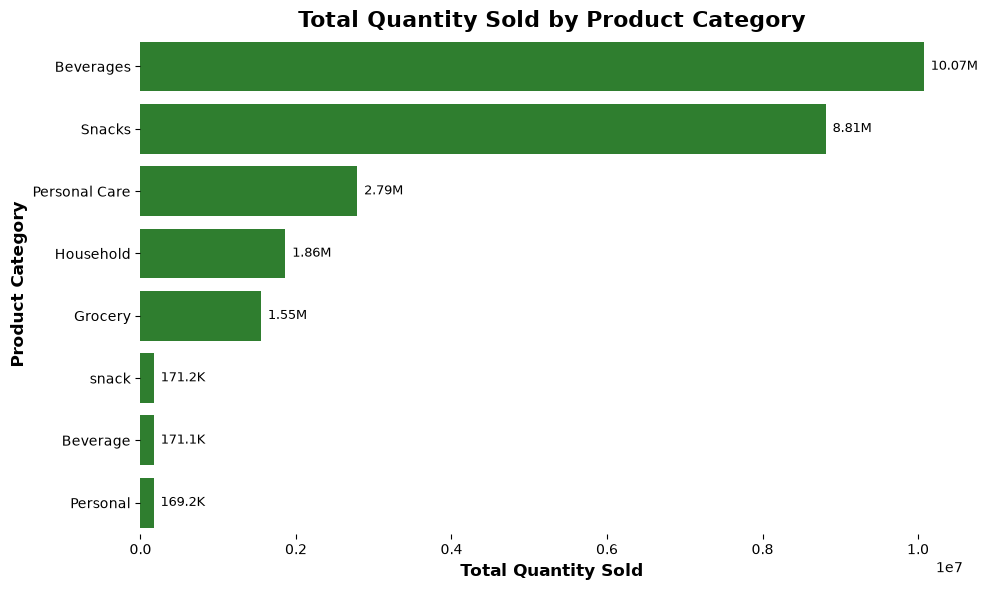

In [26]:
category_quantity = df.groupby('product_category').agg(Total_Quantity=('quantity', 'sum')).reset_index().sort_values('Total_Quantity',ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=category_quantity,x='Total_Quantity',y='product_category',color='forestgreen')
ax.set_title('Total Quantity Sold by Product Category',fontsize=16,fontweight='bold')
ax.set_xlabel('Total Quantity Sold',fontsize=12,fontweight='bold')
ax.set_ylabel('Product Category',fontsize=12,fontweight='bold')
for container in ax.containers:
    labels = [
        f"{v / 1_000_000:.2f}M" if v >= 1_000_000
        else f"{v / 1_000:.1f}K" if v >= 1_000
        else f"{v:.0f}"
        for v in container.datavalues]    
    ax.bar_label(container,labels=labels,fontsize=9,padding=5)
sns.despine(top=True,right=True,bottom=True,left=True)
plt.tight_layout()
plt.show()

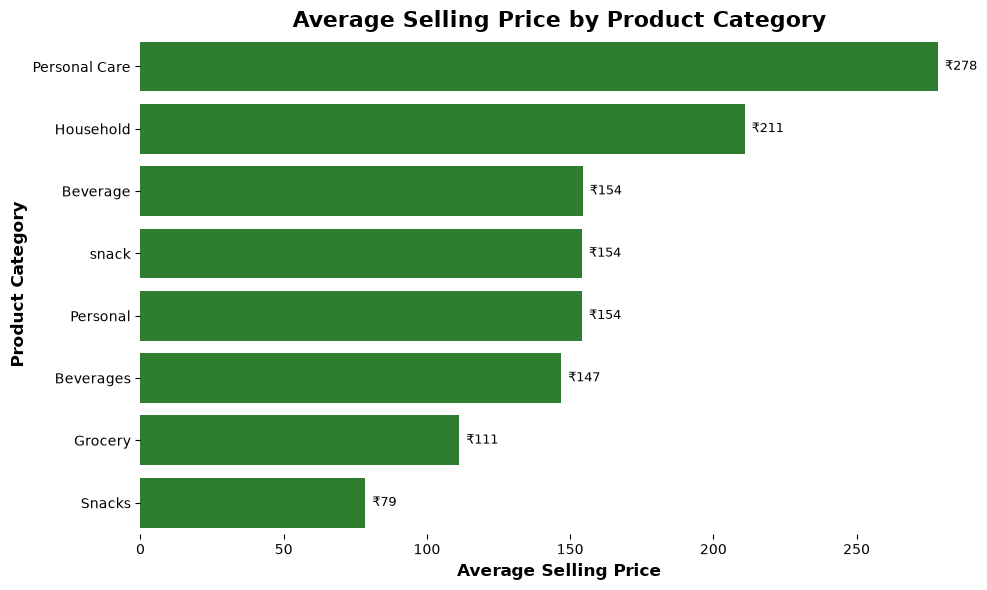

In [27]:
category_price = df.groupby('product_category').agg(Average_Selling_Price=('selling_price', 'mean')).reset_index().sort_values('Average_Selling_Price', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=category_price,x='Average_Selling_Price',y='product_category',color='forestgreen')
ax.set_title('Average Selling Price by Product Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Selling Price', fontsize=12, fontweight='bold')
ax.set_ylabel('Product Category', fontsize=12, fontweight='bold')
for container in ax.containers:
    labels = [
        f"₹{v / 100_000:.2f}L" if v >= 100_000
        else f"₹{v / 1_000:.1f}K" if v >= 1_000
        else f"₹{v:.0f}"
        for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9, padding=5)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()

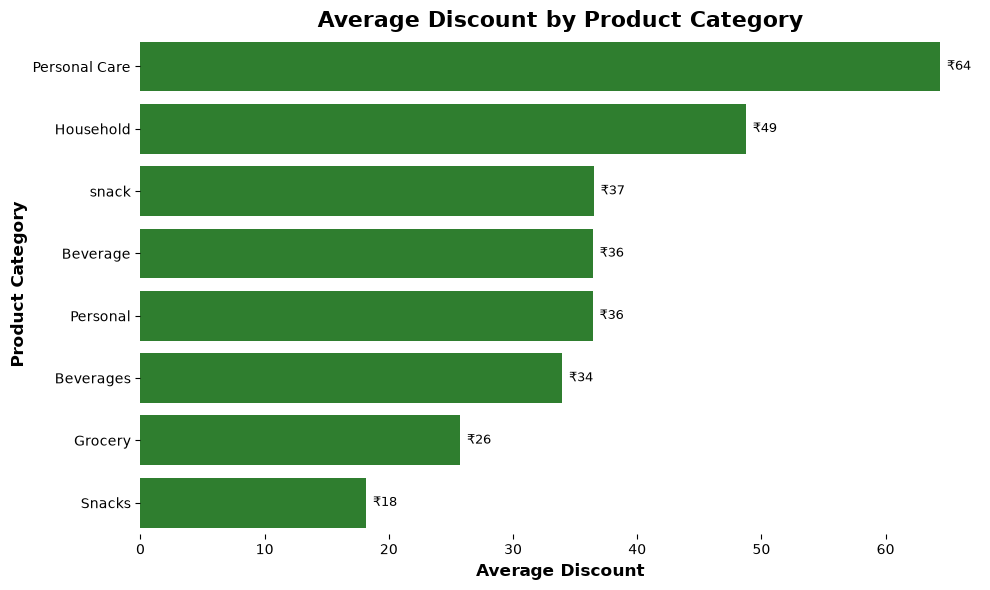

In [28]:
category_discount = df.groupby('product_category').agg(Average_Discount=('Total_Discount', 'mean')).reset_index().sort_values('Average_Discount', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=category_discount,x='Average_Discount',y='product_category',color='forestgreen')
ax.set_title('Average Discount by Product Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Discount', fontsize=12, fontweight='bold')
ax.set_ylabel('Product Category', fontsize=12, fontweight='bold')
for container in ax.containers:
    labels = [
        f"₹{v / 100_000:.2f}L" if v >= 100_000
        else f"₹{v / 1_000:.1f}K" if v >= 1_000
        else f"₹{v:.0f}"
        for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9, padding=5)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()

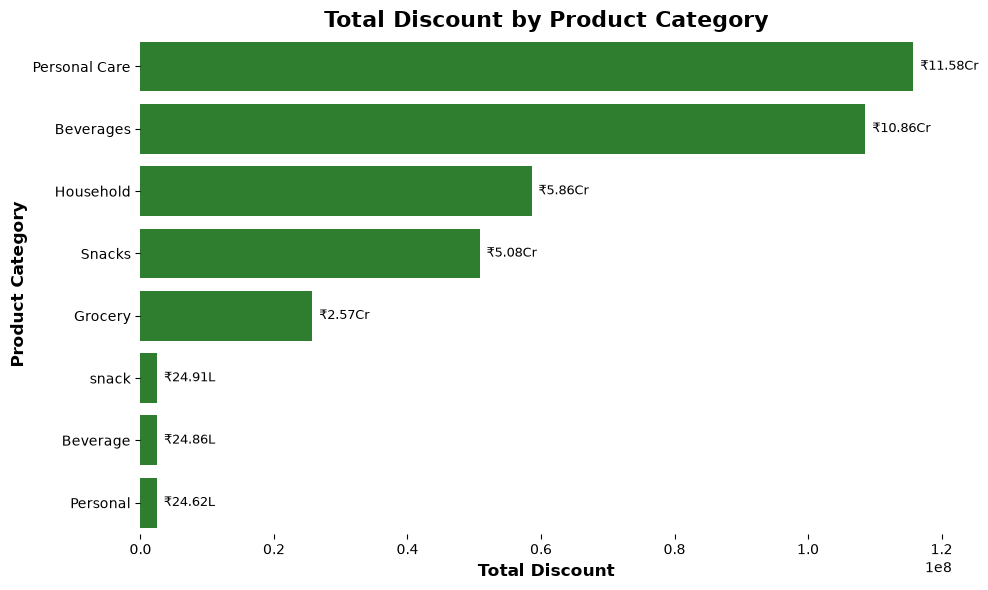

In [29]:
category_discount = df.groupby('product_category').agg(Total_Discount=('Total_Discount', 'sum')).reset_index().sort_values('Total_Discount', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=category_discount, x='Total_Discount', y='product_category', color='forestgreen')
ax.set_title('Total Discount by Product Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Discount', fontsize=12, fontweight='bold')
ax.set_ylabel('Product Category', fontsize=12, fontweight='bold')
for container in ax.containers:
    labels = [
        f"₹{v / 10_000_000:.2f}Cr" if v >= 10_000_000
        else f"₹{v / 100_000:.2f}L" if v >= 100_000
        else f"₹{v / 1_000:.1f}K" if v >= 1_000
        else f"₹{v:.0f}"
        for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9, padding=5)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()

## Charts for Dashboard 3

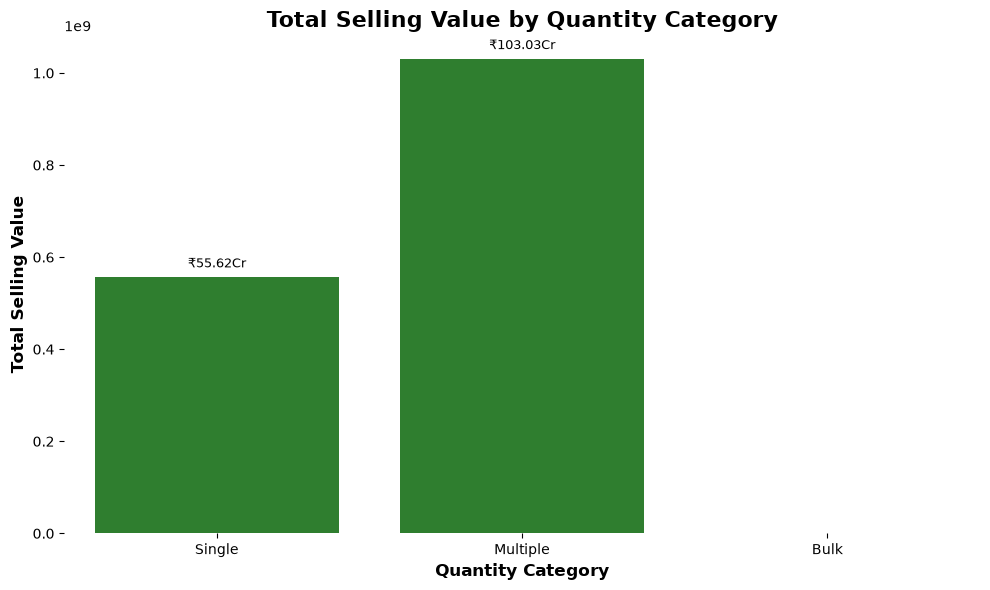

In [30]:
quantity_sales = df.groupby('Quantity_Category').agg(    Total_Selling_Value=('selling_price', 'sum')).reset_index()
quantity_order = ['Single', 'Multiple', 'Bulk']
quantity_sales['Quantity_Category'] = pd.Categorical(
    quantity_sales['Quantity_Category'],
    categories=quantity_order,
    ordered=True)
quantity_sales = quantity_sales.sort_values('Quantity_Category')
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=quantity_sales,
    x='Quantity_Category',
    y='Total_Selling_Value',
    color='forestgreen')
ax.set_title('Total Selling Value by Quantity Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Quantity Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Selling Value', fontsize=12, fontweight='bold')
for container in ax.containers:
    labels = [
        f"₹{v / 10_000_000:.2f}Cr" if v >= 10_000_000
        else f"₹{v / 100_000:.2f}L" if v >= 100_000
        else f"₹{v / 1_000:.1f}K" if v >= 1_000
        else f"₹{v:.0f}"
        for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9, padding=5)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()

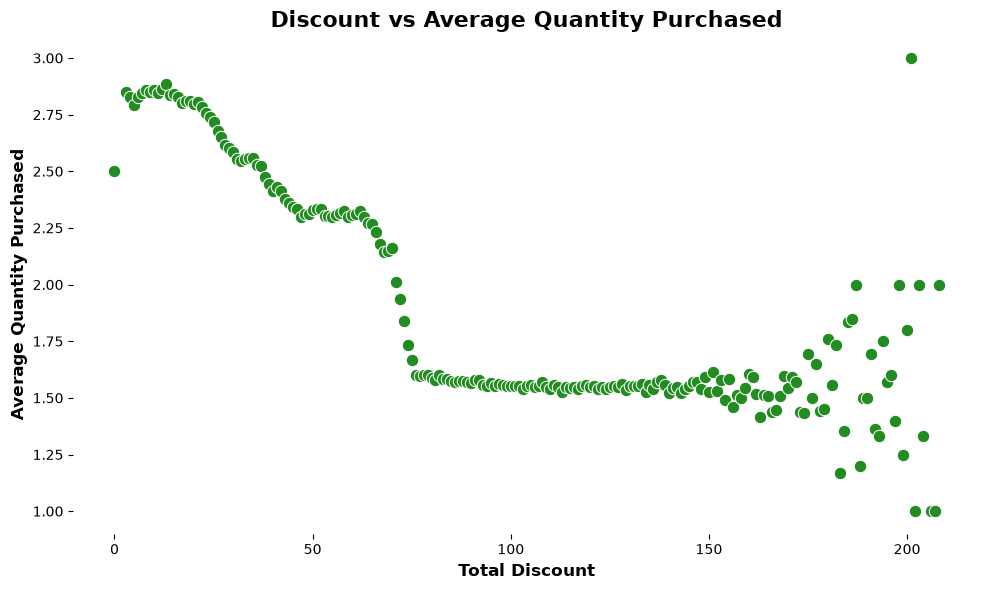

In [31]:
discount_quantity = df.groupby('Total_Discount').agg(Average_Quantity=('quantity', 'mean')).reset_index()
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=discount_quantity,x='Total_Discount',y='Average_Quantity',color='forestgreen',s=80)
ax.set_title('Discount vs Average Quantity Purchased', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Discount', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Quantity Purchased', fontsize=12, fontweight='bold')
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()

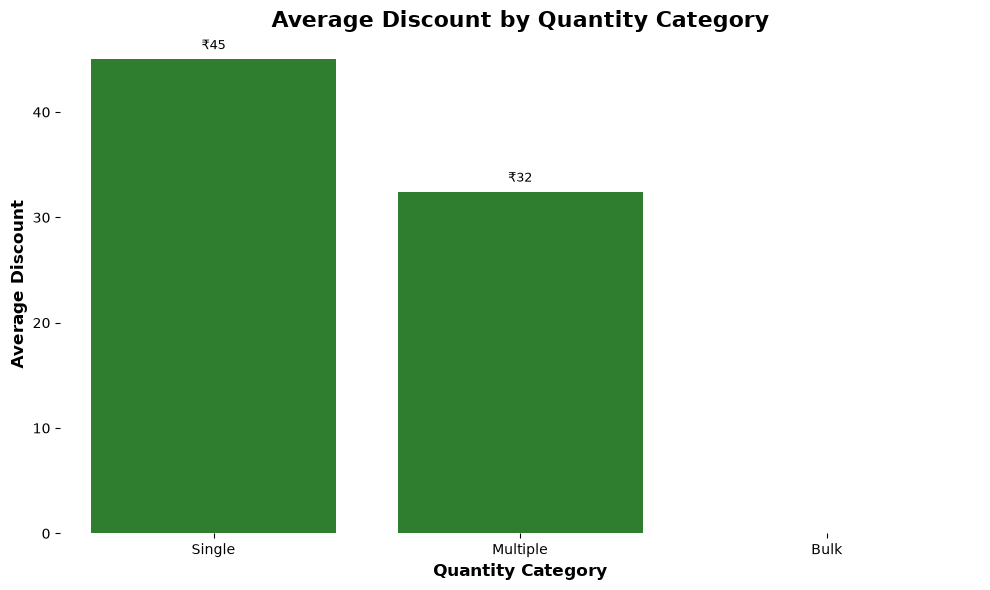

In [32]:
quantity_discount = df.groupby('Quantity_Category').agg(Average_Discount=('Total_Discount', 'mean')).reset_index()
quantity_order = ['Single', 'Multiple', 'Bulk']
quantity_discount['Quantity_Category'] = pd.Categorical(quantity_discount['Quantity_Category'],categories=quantity_order,ordered=True)
quantity_discount = quantity_discount.sort_values('Quantity_Category')
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=quantity_discount,x='Quantity_Category',y='Average_Discount',color='forestgreen')
ax.set_title('Average Discount by Quantity Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Quantity Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Discount', fontsize=12, fontweight='bold')
for container in ax.containers:
    labels = [
        f"₹{v / 100_000:.2f}L" if v >= 100_000
        else f"₹{v / 1_000:.1f}K" if v >= 1_000
        else f"₹{v:.0f}"
        for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9, padding=5)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()

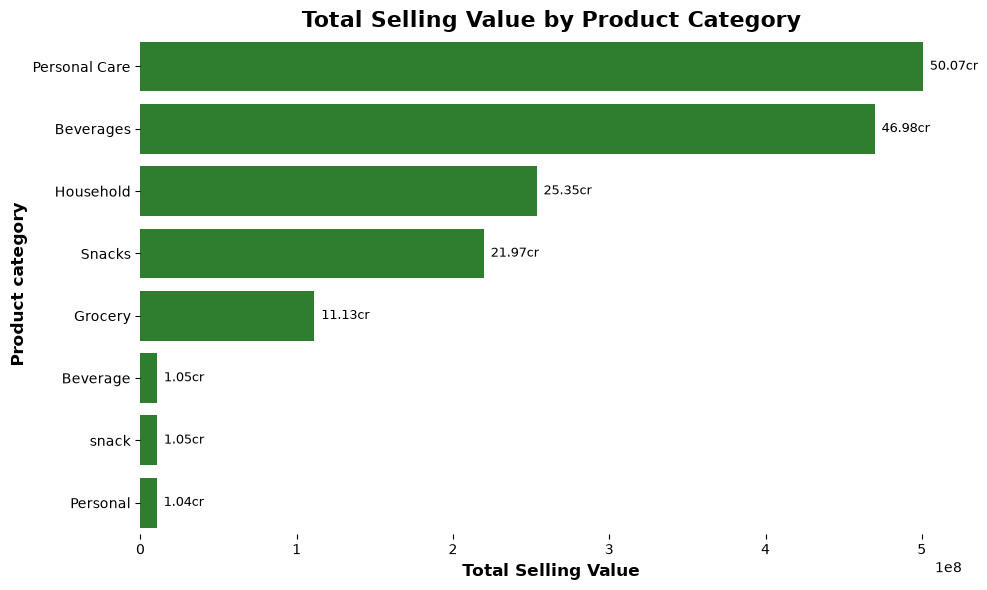

In [40]:
category_sales = df.groupby('product_category').agg(Total_Selling_Value=('selling_price', 'sum')).reset_index().sort_values('Total_Selling_Value',ascending=False)
plt.figure(figsize=(10,6))
ax=sns.barplot(category_sales,x='Total_Selling_Value',y='product_category',color='forestgreen')
ax.set_title('Total Selling Value by Product Category',fontsize=16,fontweight='bold')
ax.set_xlabel('Total Selling Value',fontsize=12,fontweight='bold')
ax.set_ylabel('Product category',fontsize=12,fontweight='bold')
for container in ax.containers:
    labels=[f'{v/10_000_000:.2f}cr' if v >= 10_000_000
           else f'{v/100_000:.2f}L' if v >= 100_000
           else f'{v/1_000:.1f}K'
           for v in container.datavalues]
    ax.bar_label(container,labels=labels,fontsize=9,padding=5)
sns.despine(top=True, right=True,bottom=True,left=True)
plt.tight_layout()
plt.show()

## Charts for Dashboard 4

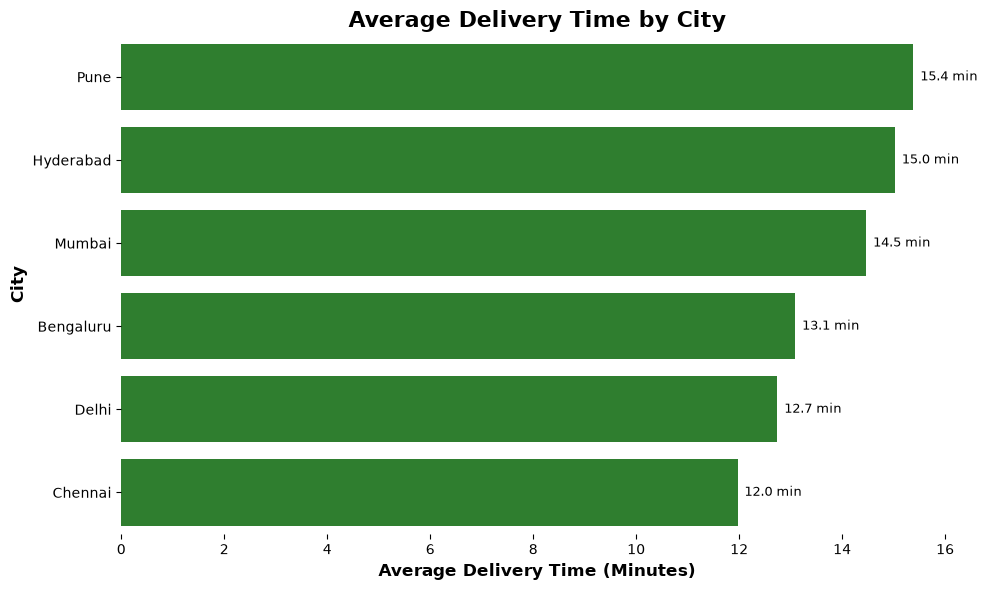

In [34]:
city_delivery = df.groupby('city').agg(Average_Delivery_Time=('delivery_time_min', 'mean')).reset_index().sort_values('Average_Delivery_Time', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=city_delivery, x='Average_Delivery_Time', y='city', color='forestgreen')
ax.set_title('Average Delivery Time by City', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Delivery Time (Minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('City', fontsize=12, fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f min', fontsize=9, padding=5)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()

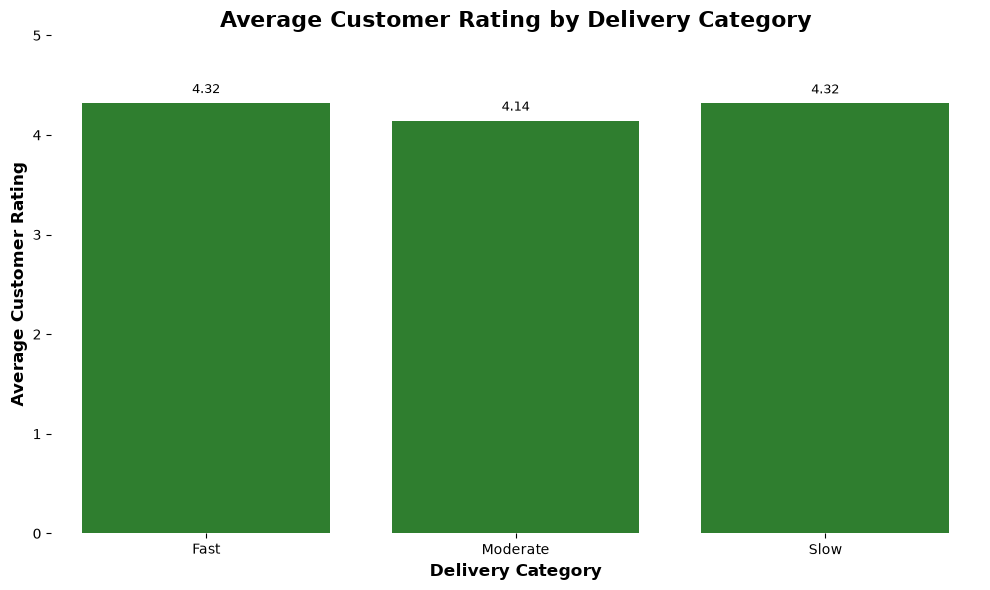

In [35]:
delivery_rating = df.groupby('Delivery_Category').agg( Average_Rating=('customer_rating', lambda x: pd.to_numeric(x, errors='coerce').mean())).reset_index()
delivery_order = ['Fast', 'Moderate', 'Slow']
delivery_rating['Delivery_Category'] = pd.Categorical(delivery_rating['Delivery_Category'],categories=delivery_order,ordered=True)
delivery_rating = delivery_rating.sort_values('Delivery_Category')
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=delivery_rating, x='Delivery_Category', y='Average_Rating', color='forestgreen')
ax.set_title('Average Customer Rating by Delivery Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Delivery Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Customer Rating', fontsize=12, fontweight='bold')
ax.set_ylim(0, 5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9, padding=5)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()

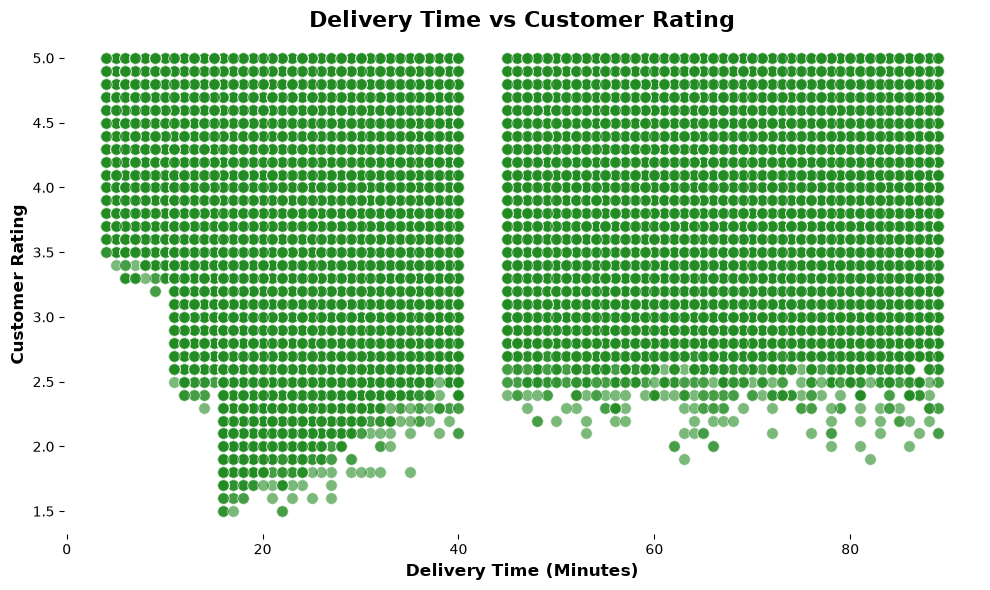

In [36]:
rating_delivery = df.copy()
rating_delivery['customer_rating'] = pd.to_numeric(rating_delivery['customer_rating'],errors='coerce')
rating_delivery = rating_delivery.dropna(subset=['customer_rating', 'delivery_time_min'])
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=rating_delivery,x='delivery_time_min',y='customer_rating',color='forestgreen',s=70,alpha=0.6)
ax.set_title('Delivery Time vs Customer Rating', fontsize=16, fontweight='bold')
ax.set_xlabel('Delivery Time (Minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Customer Rating', fontsize=12, fontweight='bold')
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()

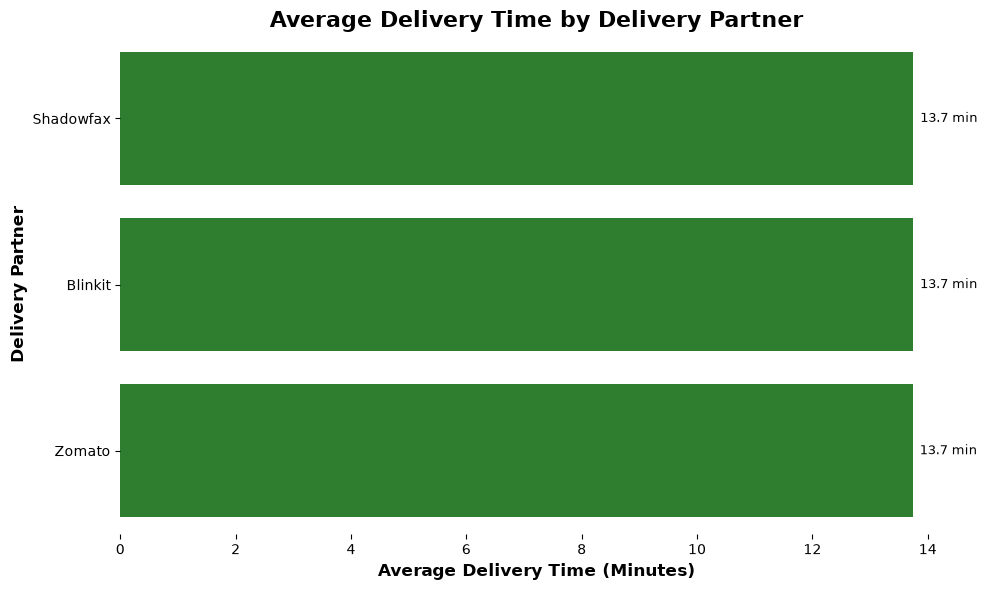

In [37]:
partner_delivery = df.groupby('delivery_partner').agg(Average_Delivery_Time=('delivery_time_min', 'mean')).reset_index().sort_values('Average_Delivery_Time', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=partner_delivery, x='Average_Delivery_Time', y='delivery_partner', color='forestgreen')
ax.set_title('Average Delivery Time by Delivery Partner', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Delivery Time (Minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Delivery Partner', fontsize=12, fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f min', fontsize=9, padding=5)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()

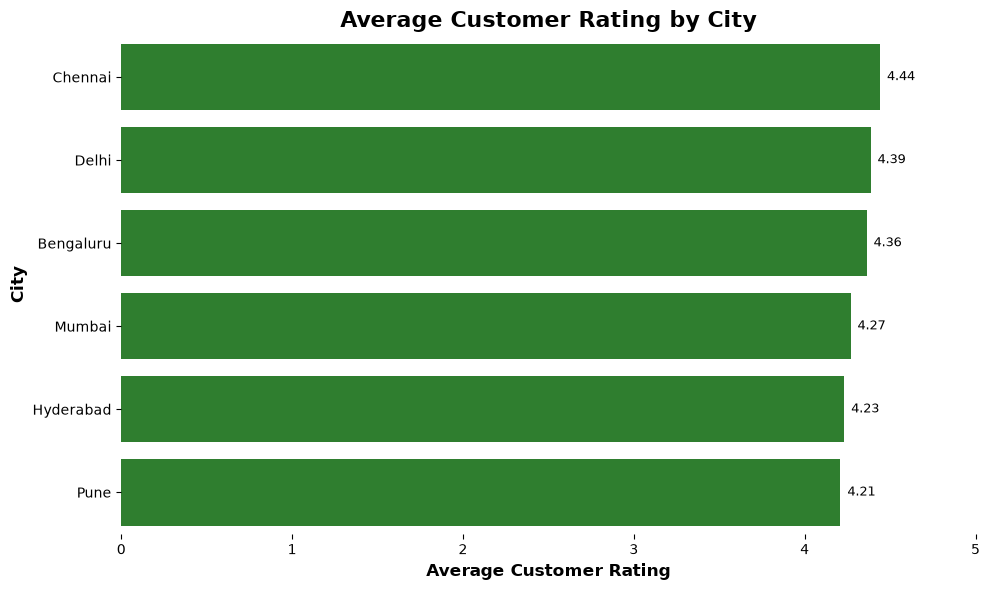

In [38]:
city_rating = df.copy()
city_rating['customer_rating'] = pd.to_numeric(city_rating['customer_rating'],errors='coerce')
city_rating = city_rating.groupby('city').agg(Average_Rating=('customer_rating', 'mean')).reset_index().sort_values('Average_Rating', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=city_rating, x='Average_Rating', y='city', color='forestgreen')
ax.set_title('Average Customer Rating by City', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Customer Rating', fontsize=12, fontweight='bold')
ax.set_ylabel('City', fontsize=12, fontweight='bold')
ax.set_xlim(0, 5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9, padding=5)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()

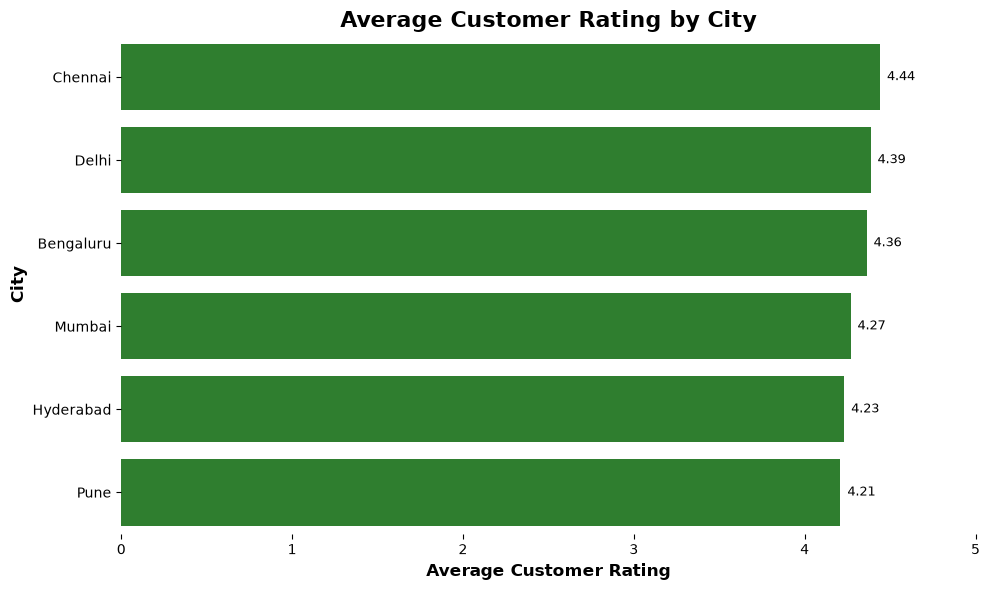

In [39]:
city_rating = df.copy()
city_rating['customer_rating'] = pd.to_numeric(city_rating['customer_rating'],errors='coerce')
city_rating = city_rating.groupby('city').agg(
    Average_Rating=('customer_rating', 'mean')
).reset_index().sort_values('Average_Rating', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=city_rating, x='Average_Rating', y='city', color='forestgreen')
ax.set_title('Average Customer Rating by City', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Customer Rating', fontsize=12, fontweight='bold')
ax.set_ylabel('City', fontsize=12, fontweight='bold')
ax.set_xlim(0, 5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9, padding=5)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()